In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

In [5]:
df = pd.read_csv('Lab_Work/data/razor_data.csv')
df['Power (mW)'] = pd.to_numeric(df['Power (mW)'], errors='coerce')
df['Distance (mm)'] = pd.to_numeric(df['Distance (mm)'], errors='coerce')
df_clean = df.dropna().copy()

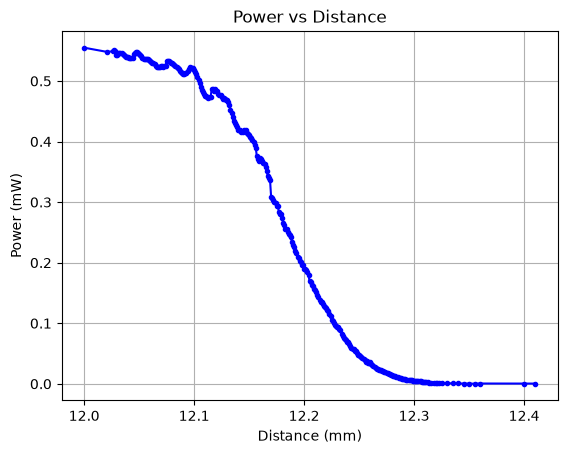

In [6]:


plt.plot(df_clean['Distance (mm)'], df_clean['Power (mW)'], marker='.', linestyle='-', color='blue')

plt.title('Power vs Distance')
plt.xlabel('Distance (mm)')
plt.ylabel('Power (mW)')
plt.grid(True)

plt.show()

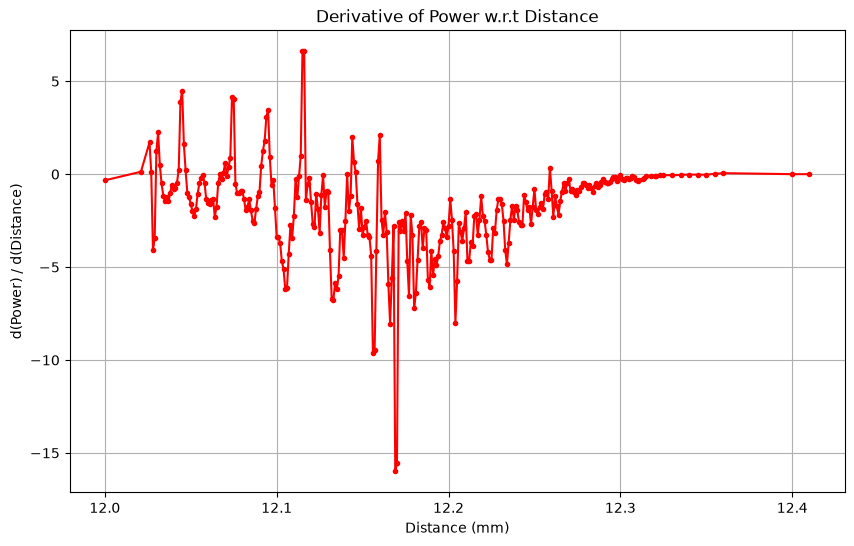

In [7]:
df_clean = df_clean.sort_values('Distance (mm)').reset_index(drop=True)

df_clean['Derivative'] = np.gradient(df_clean['Power (mW)'], df_clean['Distance (mm)'])

plt.figure(figsize=(10,6))
plt.plot(df_clean['Distance (mm)'], df_clean['Derivative'], color='red', marker='.')

plt.title('Derivative of Power w.r.t Distance')
plt.xlabel('Distance (mm)')
plt.ylabel('d(Power) / d(Distance)')
plt.grid(True)

plt.show()

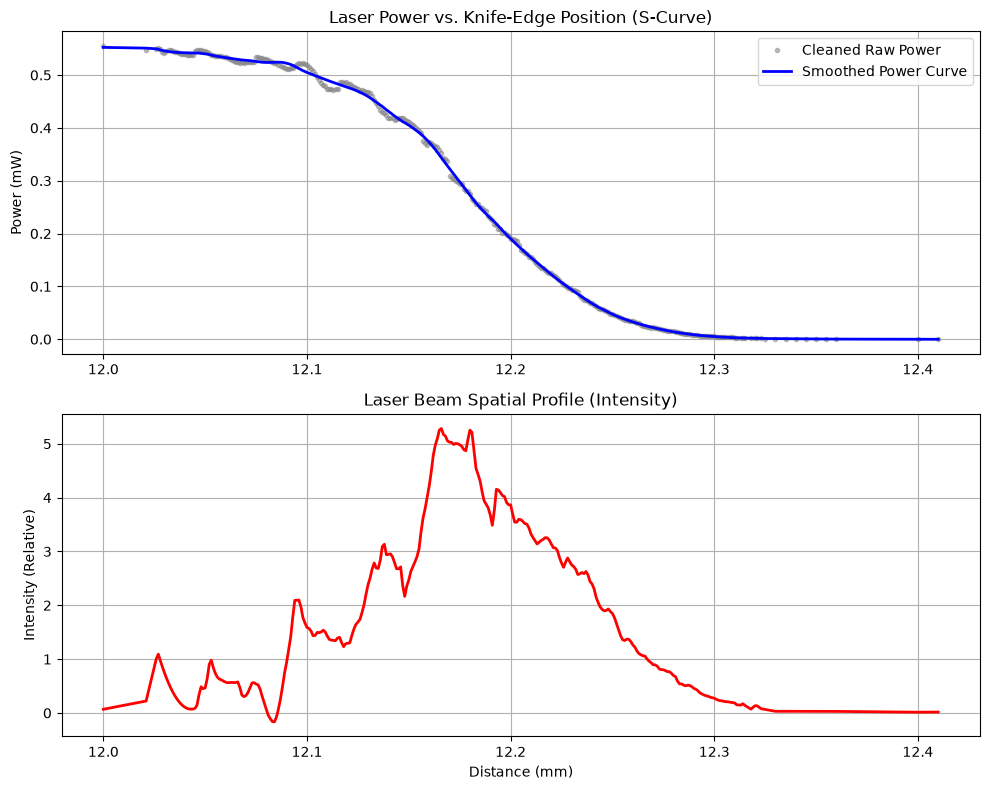

In [9]:
df_clean = df.dropna().sort_values('Distance (mm)').reset_index(drop=True)

window = 5
rolling_median = df_clean['Power (mW)'].rolling(window=window, center=True).median()
outlier_idx = np.abs(df_clean['Power (mW)'] - rolling_median) > 0.05 
df_clean.loc[outlier_idx, 'Power (mW)'] = np.nan
df_clean = df_clean.dropna().reset_index(drop=True)

smoothed_power = savgol_filter(df_clean['Power (mW)'], window_length=45, polyorder=3)

beam_profile = -1 * np.gradient(smoothed_power, df_clean['Distance (mm)'])
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
ax1.plot(df_clean['Distance (mm)'], df_clean['Power (mW)'], '.', label='Cleaned Raw Power', color='grey', alpha=0.5)
ax1.plot(df_clean['Distance (mm)'], smoothed_power, label='Smoothed Power Curve', color='blue', linewidth=2)
ax1.set_title('Laser Power vs. Knife-Edge Position (S-Curve)')
ax1.set_ylabel('Power (mW)')
ax1.grid(True)
ax1.legend()

ax2.plot(df_clean['Distance (mm)'], beam_profile, color='red', linewidth=2)
ax2.set_title('Laser Beam Spatial Profile (Intensity)')
ax2.set_xlabel('Distance (mm)')
ax2.set_ylabel('Intensity (Relative)')
ax2.grid(True)

plt.tight_layout()
plt.show()